# What *Really* Predicts a Student's Exam Score?

### A visual story from 80,000 students

In `day_2` we explored the smaller `student_habits_performance.csv` using **pandas only**.
Here we move to the much richer **`enhanced_student_habits_performance_dataset.csv`**
(80,000 students × 31 columns) and let **matplotlib + seaborn** tell the story.

We'll chase one question:

> Of all the things we measure about a student — their sleep, diet, screen time, income,
> motivation, study habits — **which ones actually predict how well they do on the exam?**

The answer is more surprising (and more human) than you'd think.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# A clean, consistent look for every chart in the notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# A few brand colors we'll reuse so the story feels cohesive
ACCENT   = "#2A9D8F"   # teal  - the "hero" colour
WARM     = "#E76F51"   # coral - for warnings / risk
MUTED    = "#9AA0A6"   # grey  - for "doesn't matter"


## 1. Load the data & first look

Same first steps as the `day_2` pandas exploration — shape, columns, types, missing values —
just on a much bigger dataset.

In [2]:
df = pd.read_csv("enhanced_student_habits_performance_dataset.csv")
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [3]:
n_rows, n_cols = df.shape
print(f"Number of rows:    {n_rows:,}")
print(f"Number of columns: {n_cols}")
print(f"Missing values:    {df.isnull().sum().sum()}")
print(f"Duplicate rows:    {df.duplicated().sum()}")

Number of rows:    80,000
Number of columns: 31
Missing values:    0
Duplicate rows:    0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  str    
 3   major                          80000 non-null  str    
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  str    
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  str    
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null  str    
 1

The dataset is **pristine** — 80,000 rows, no missing values, no duplicates. That's rare in
real life, so we can dive straight into the analysis without any cleaning.

Let's see the numeric summary.

In [5]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
student_id,80000.0,139999.50,23094.16,100000.00,119999.75,139999.50,159999.25,179999.0
age,80000.0,22.00,3.75,16.00,19.00,22.00,25.00,28.0
study_hours_per_day,80000.0,4.17,2.00,0.00,2.80,4.13,5.50,12.0
social_media_hours,80000.0,2.50,1.45,0.00,1.20,2.50,3.80,5.0
netflix_hours,80000.0,2.00,1.16,0.00,1.00,2.00,3.00,4.0
attendance_percentage,80000.0,69.97,17.33,40.00,55.00,69.90,84.90,100.0
sleep_hours,80000.0,7.02,1.47,4.00,6.00,7.00,8.00,12.0
exercise_frequency,80000.0,3.52,2.29,0.00,2.00,4.00,6.00,7.0
mental_health_rating,80000.0,6.80,1.92,1.00,5.50,6.90,8.20,10.0
previous_gpa,80000.0,3.60,0.46,1.64,3.27,3.79,4.00,4.0


A couple of things already stand out from the summary:

- **`exam_score`** averages ~89 and is heavily skewed toward the top (median 93, capped at 100).
- **`previous_gpa`** is similarly high and capped at 4.0.
- Habits look healthy on average: ~7 hours sleep, ~4 study hours/day, mental-health ~6.8/10.

## 2. The thing we're trying to explain: `exam_score`

Before asking *what predicts* the exam score, let's look at the score itself.

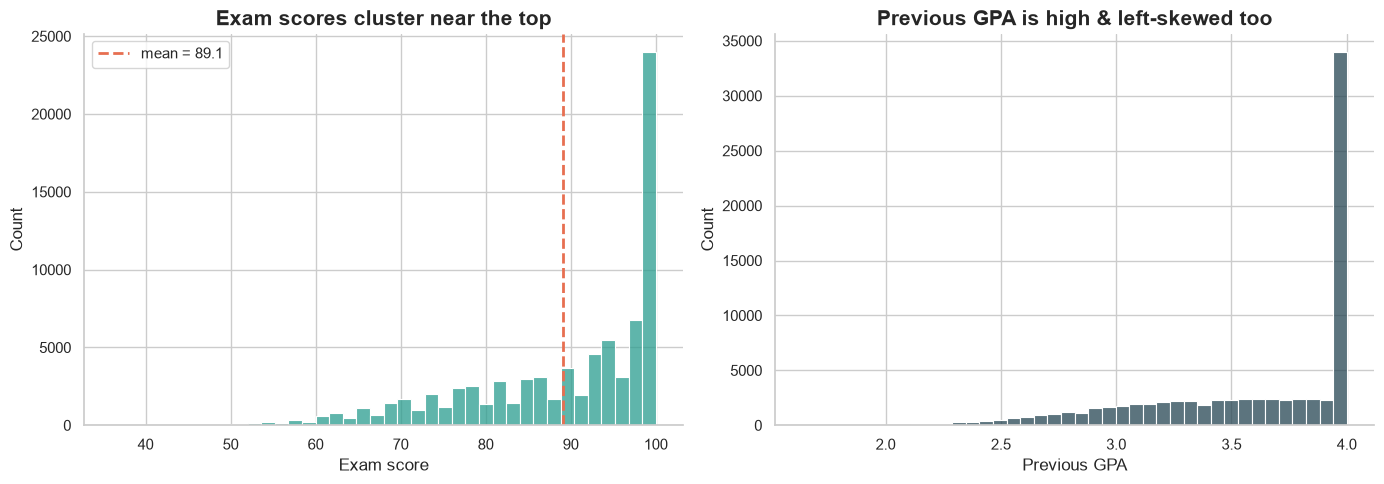

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["exam_score"], bins=40, color=ACCENT, ax=axes[0])
axes[0].axvline(df["exam_score"].mean(), color=WARM, ls="--", lw=2,
                label=f"mean = {df['exam_score'].mean():.1f}")
axes[0].set_title("Exam scores cluster near the top")
axes[0].set_xlabel("Exam score")
axes[0].legend()

sns.histplot(df["previous_gpa"], bins=40, color="#264653", ax=axes[1])
axes[1].set_title("Previous GPA is high & left-skewed too")
axes[1].set_xlabel("Previous GPA")

plt.tight_layout()
plt.show()

Both distributions lean high and share the same *shape*. That's our first hint that the two
might be deeply linked — let's test it.

## 3. What correlates with what?

A correlation heatmap of every numeric feature is the fastest way to see the structure of the data.

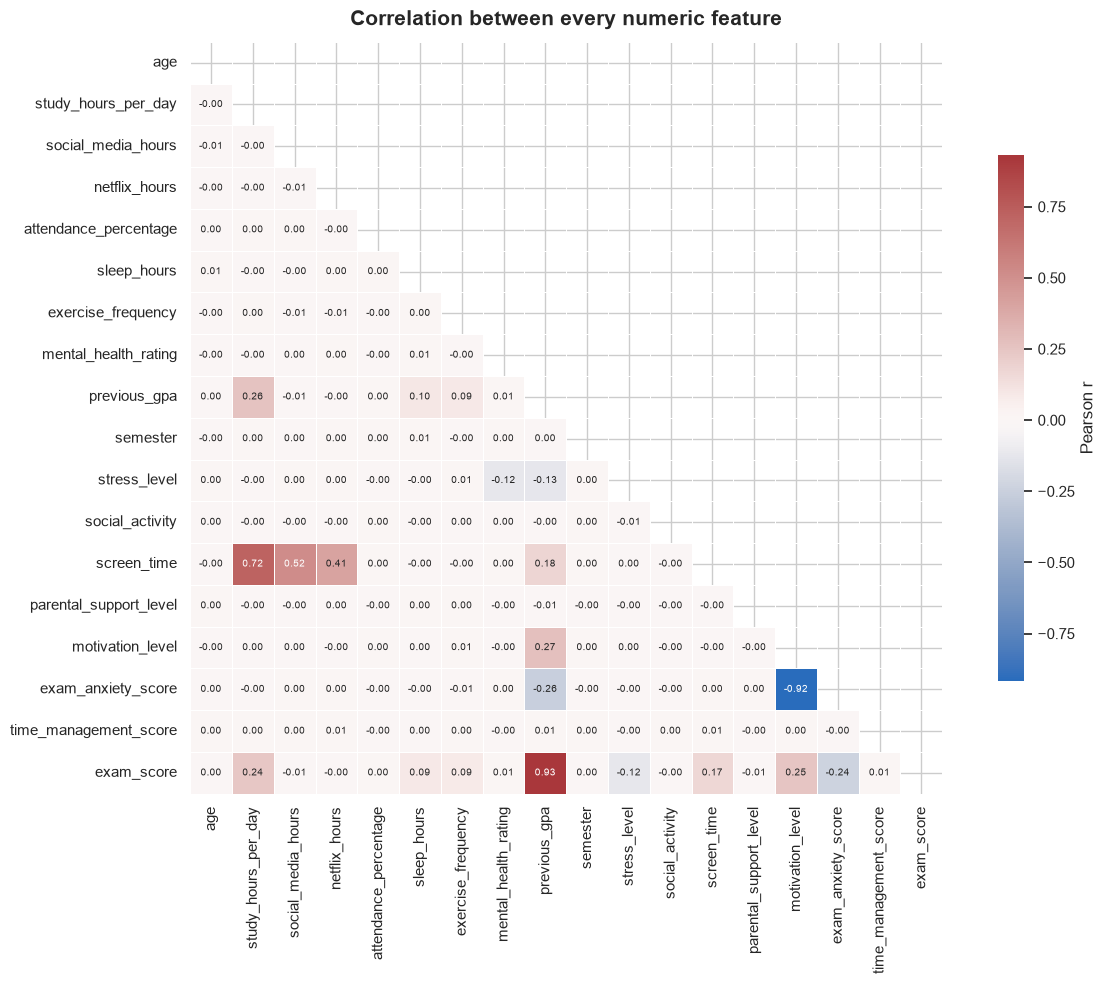

In [7]:
num = df.select_dtypes("number").drop(columns=["student_id"])
corr = num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(13, 10))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .7, "label": "Pearson r"},
            annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation between every numeric feature", pad=12)
plt.tight_layout()
plt.show()

Three bright spots jump out of the heatmap:

1. **`previous_gpa` ↔ `exam_score`** — glowing red, by far the strongest relationship.
2. **`motivation_level` ↔ `exam_anxiety_score`** — a strong *negative* band (a mirror image).
3. **`screen_time`** lights up with study/social-media/Netflix hours — because it's essentially their sum.

Let's zoom into the one that matters most for our question.

## 4. The headline: one feature towers over the rest

If we rank every numeric feature by how strongly it correlates with the exam score, the picture
is almost comically lopsided.

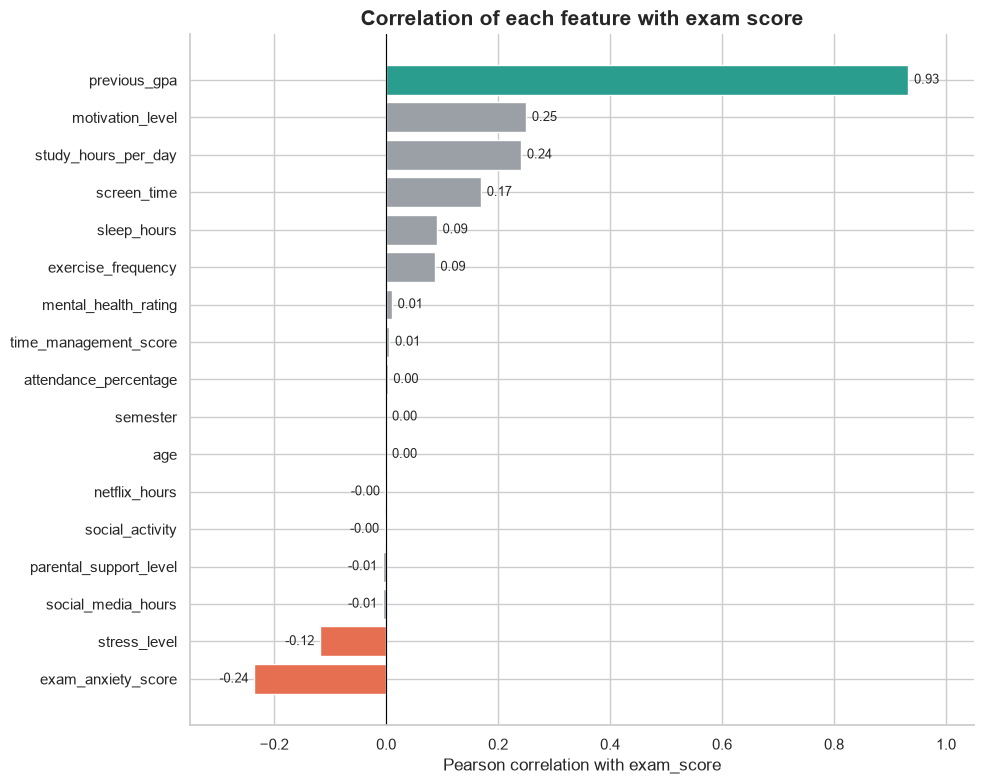

In [8]:
score_corr = (num.corr()["exam_score"]
              .drop("exam_score")
              .sort_values())

colors = [ACCENT if abs(v) >= 0.5 else (WARM if v < -0.1 else MUTED) for v in score_corr]

plt.figure(figsize=(10, 8))
plt.barh(score_corr.index, score_corr.values, color=colors)
plt.axvline(0, color="black", lw=.8)
plt.title("Correlation of each feature with exam score")
plt.xlabel("Pearson correlation with exam_score")
for i, v in enumerate(score_corr.values):
    plt.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.2f}",
             va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.xlim(-0.35, 1.05)
plt.tight_layout()
plt.show()

**`previous_gpa` (r ≈ 0.93) dwarfs everything else.** The next closest features —
motivation, study hours, exam anxiety — sit around ±0.25. Almost everything we intuitively
believe matters (sleep, diet, attendance, time-management, family income, internet quality)
is **statistically flat**, hugging zero.

Let's make that previous-GPA relationship concrete.

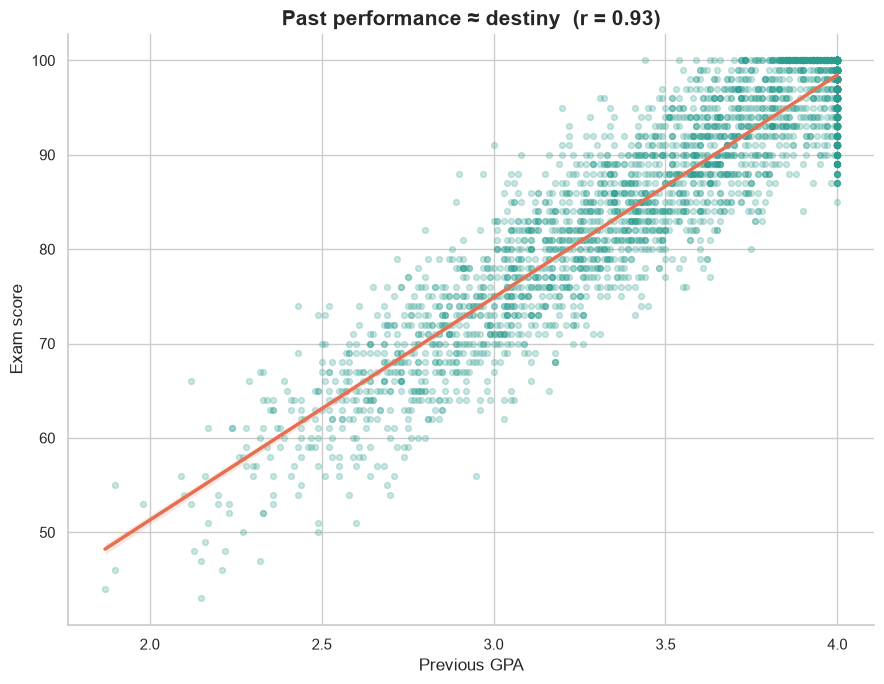

In [9]:
sample = df.sample(4000, random_state=42)   # 4k points keeps the scatter readable
plt.figure(figsize=(9, 7))
sns.regplot(data=sample, x="previous_gpa", y="exam_score",
            scatter_kws={"alpha": .25, "s": 18, "color": ACCENT},
            line_kws={"color": WARM, "lw": 2.5})
r = df["previous_gpa"].corr(df["exam_score"])
plt.title(f"Past performance ≈ destiny  (r = {r:.2f})")
plt.xlabel("Previous GPA")
plt.ylabel("Exam score")
plt.tight_layout()
plt.show()

Knowing nothing but a student's **previous GPA** lets you predict their exam score with
remarkable accuracy. Where they study, how they sleep, what they eat — all of it is noise next
to the momentum of past performance.

## 5. The habits we *assume* matter… barely do

It's worth seeing this directly. Below is the average exam score across the categories we'd
expect to be decisive: diet, internet quality, and family income. Watch the y-axis — it barely moves.

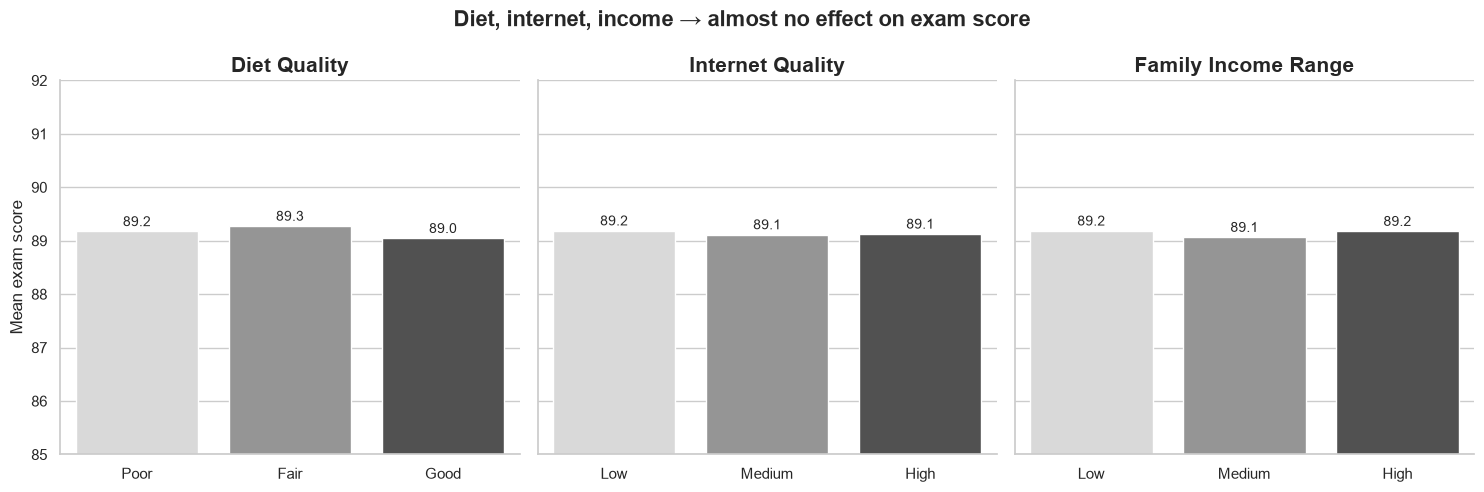

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
groups = [("diet_quality", ["Poor", "Fair", "Good"]),
          ("internet_quality", ["Low", "Medium", "High"]),
          ("family_income_range", ["Low", "Medium", "High"])]

for ax, (col, order) in zip(axes, groups):
    means = df.groupby(col)["exam_score"].mean().reindex(order)
    sns.barplot(x=means.index, y=means.values, order=order,
                hue=means.index, palette="Greys", legend=False, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.1, f"{v:.1f}", ha="center", fontsize=10)

axes[0].set_ylabel("Mean exam score")
fig.suptitle("Diet, internet, income → almost no effect on exam score",
             fontsize=16, fontweight="bold")
plt.ylim(85, 92)
plt.tight_layout()
plt.show()

Across every level — eating poorly vs. well, slow vs. fast internet, low vs. high income —
the mean exam score stays within **less than one point** of 89. In this dataset, these
advantages simply don't translate into better exam outcomes.

## 6. One habit that *does* move the needle: **where you study**

Among all the lifestyle variables, the student's chosen **study environment** stands out.

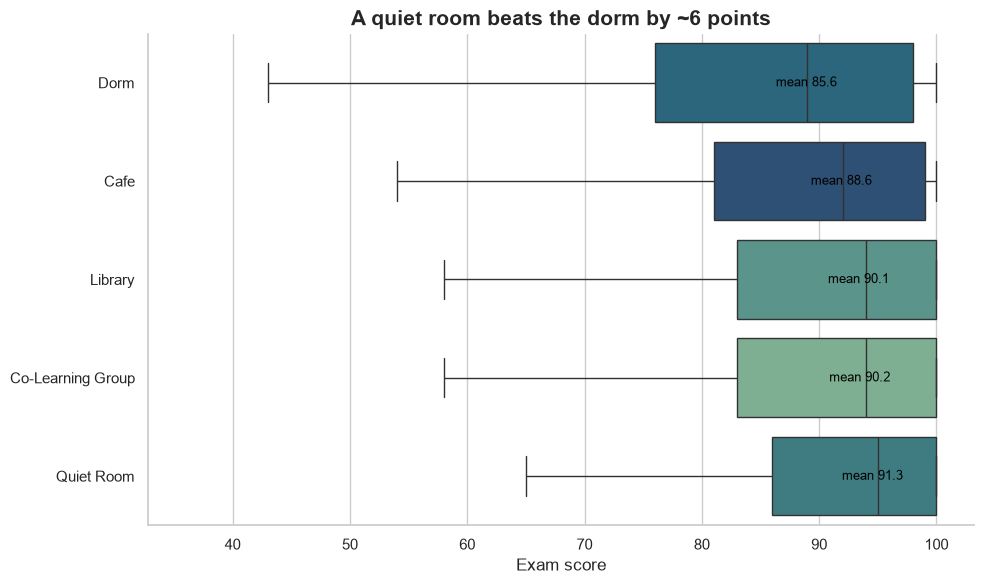

In [11]:
env_order = (df.groupby("study_environment")["exam_score"]
             .mean().sort_values().index)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="exam_score", y="study_environment", order=env_order,
            hue="study_environment", palette="crest", legend=False,
            fliersize=0)
means = df.groupby("study_environment")["exam_score"].mean().reindex(env_order)
for i, v in enumerate(means.values):
    plt.text(v, i, f"  mean {v:.1f}", va="center", fontsize=9, color="black")
plt.title("A quiet room beats the dorm by ~6 points")
plt.xlabel("Exam score")
plt.ylabel("")
plt.tight_layout()
plt.show()

Students who study in a **Quiet Room (91.3)**, **Library** or **Co-Learning Group (~90)**
clearly outscore those studying in the **Dorm (85.6)** or **Cafe**. A ~6-point swing — larger
than diet, income and internet *combined*. Environment is the one controllable habit that
genuinely shows up in the results.

## 7. The mirror: motivation and exam anxiety

The heatmap flagged a strong negative link between **motivation** and **exam anxiety**.
It turns out to be almost a perfect inverse relationship.

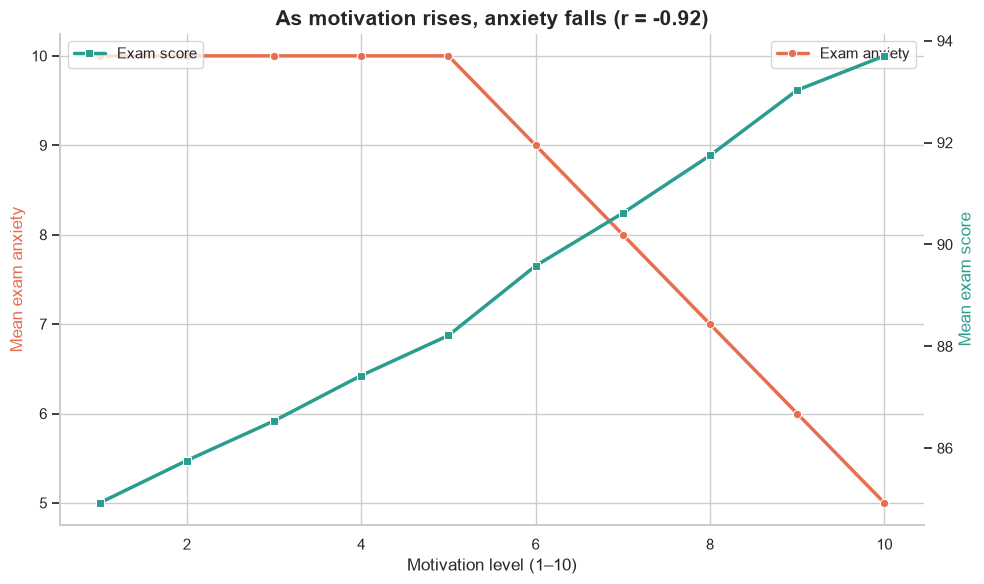

In [12]:
rel = (df.groupby("motivation_level")
       .agg(mean_anxiety=("exam_anxiety_score", "mean"),
            mean_score=("exam_score", "mean"))
       .reset_index())

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(data=rel, x="motivation_level", y="mean_anxiety",
             marker="o", color=WARM, lw=2.5, ax=ax1, label="Exam anxiety")
ax1.set_ylabel("Mean exam anxiety", color=WARM)
ax1.set_xlabel("Motivation level (1–10)")

ax2 = ax1.twinx()
sns.lineplot(data=rel, x="motivation_level", y="mean_score",
             marker="s", color=ACCENT, lw=2.5, ax=ax2, label="Exam score")
ax2.set_ylabel("Mean exam score", color=ACCENT)
ax2.grid(False)

r = df["motivation_level"].corr(df["exam_anxiety_score"])
ax1.set_title(f"As motivation rises, anxiety falls (r = {r:.2f})")
fig.tight_layout()
plt.show()

The two are nearly two sides of the same coin: **the most motivated students report the least
exam anxiety**, and they also score a little higher. Motivation and anxiety together form the
clearest *psychological* axis in the data — which becomes important in the final chapter.

## 8. Who's at risk of dropping out? (It's not who you'd guess)

Only **2%** of students are flagged as a dropout risk. The striking part is *what separates them* —
and it isn't their grades.

In [13]:
print("Dropout rate: {:.1%}".format((df['dropout_risk'] == 'Yes').mean()))

compare = (df.groupby("dropout_risk")[
    ["previous_gpa", "study_hours_per_day", "attendance_percentage",
     "stress_level", "motivation_level"]].mean().round(2))
compare

Dropout rate: 2.0%


,previous_gpa,study_hours_per_day,attendance_percentage,stress_level,motivation_level
dropout_risk,,,,,
No,3.61,4.17,69.98,4.93,5.56
Yes,3.30,4.18,69.20,8.89,1.98


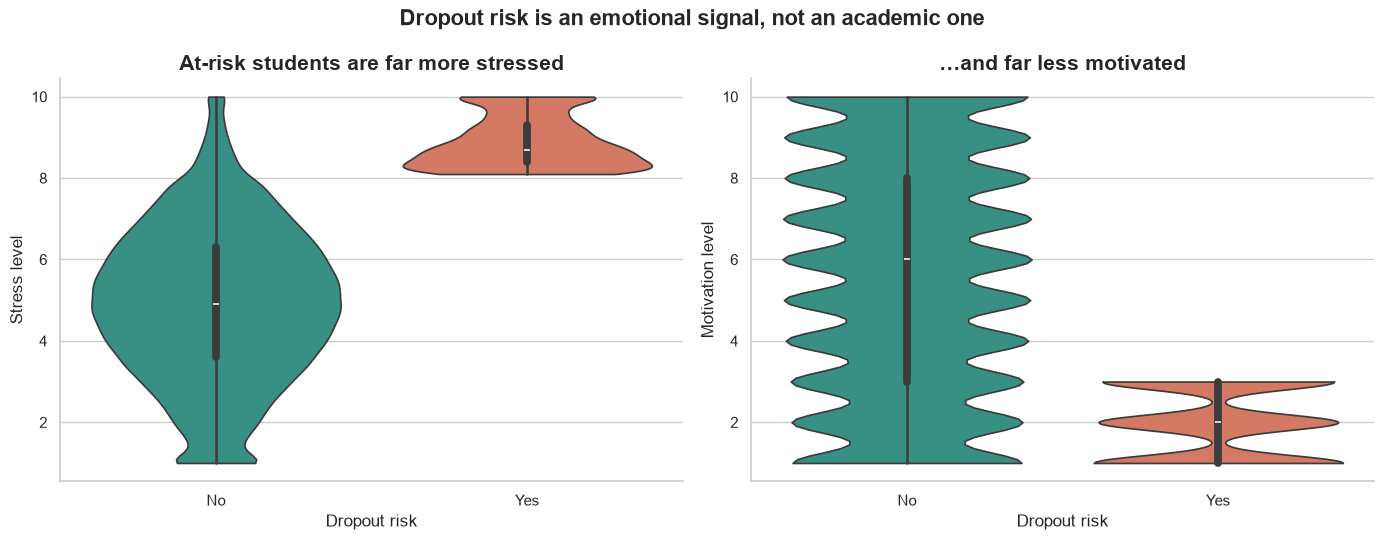

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.violinplot(data=df, x="dropout_risk", y="stress_level",
               hue="dropout_risk", palette={"No": ACCENT, "Yes": WARM},
               order=["No", "Yes"], legend=False, ax=axes[0], cut=0)
axes[0].set_title("At-risk students are far more stressed")
axes[0].set_xlabel("Dropout risk")
axes[0].set_ylabel("Stress level")

sns.violinplot(data=df, x="dropout_risk", y="motivation_level",
               hue="dropout_risk", palette={"No": ACCENT, "Yes": WARM},
               order=["No", "Yes"], legend=False, ax=axes[1], cut=0)
axes[1].set_title("…and far less motivated")
axes[1].set_xlabel("Dropout risk")
axes[1].set_ylabel("Motivation level")

fig.suptitle("Dropout risk is an emotional signal, not an academic one",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

The numbers are stark. Students flagged as dropout risks have **nearly identical GPAs,
study hours and attendance** to everyone else — but their **stress is almost double**
(8.9 vs 4.9) and their **motivation has collapsed** (2.0 vs 5.6).

Dropout risk, in this dataset, is written in *how a student feels*, not in *how they perform*.

## 9. Seeing two habits at once: 3D surfaces

Every chart so far shows exam score against **one** feature. A **surface plot** lets us see how
the score responds to **two** features at the same time — revealing ridges, cliffs and synergies
that a flat chart hides.

**How to read it:** we bin each feature into a grid, average the exam score inside every cell, and
drape a surface over the result. Height (and colour) = mean exam score; empty cells are smoothly
interpolated.

We start with the requested pair — **screen time × study hours** — then show the two most
*interesting* combinations the data offers (chosen by which pairs make the surface vary the most).

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables the 3d projection)

def make_surface(fx, fy, bins=14, clip=(1, 99)):
    """Bin two features into a grid and average exam_score in each cell."""
    d = df[[fx, fy, "exam_score"]].copy()
    for c in (fx, fy):                       # trim sparse tails so the grid is well-filled
        lo, hi = np.percentile(d[c], clip)
        d = d[(d[c] >= lo) & (d[c] <= hi)]
    xe = np.linspace(d[fx].min(), d[fx].max(), bins + 1)
    ye = np.linspace(d[fy].min(), d[fy].max(), bins + 1)
    d["xb"] = pd.cut(d[fx], xe, include_lowest=True)
    d["yb"] = pd.cut(d[fy], ye, include_lowest=True)
    Z = d.groupby(["yb", "xb"], observed=False)["exam_score"].mean().unstack()
    Z = (Z.interpolate(axis=0, limit_direction="both")
           .interpolate(axis=1, limit_direction="both"))   # fill empty cells
    xc = (xe[:-1] + xe[1:]) / 2
    yc = (ye[:-1] + ye[1:]) / 2
    X, Y = np.meshgrid(xc, yc)
    return X, Y, Z.values

def plot_surface(fx, fy, title, cmap="viridis", elev=26, azim=-58):
    X, Y, Z = make_surface(fx, fy)
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap=cmap, edgecolor="none",
                           antialiased=True, alpha=.96)
    ax.set_xlabel("\n" + fx.replace("_", " "))
    ax.set_ylabel("\n" + fy.replace("_", " "))
    ax.set_zlabel("mean exam score")
    ax.set_title(title, pad=24)
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surf, shrink=.5, aspect=12, pad=.1, label="mean exam score")
    plt.tight_layout()
    plt.show()

### 9.1 Requested: screen time × study hours

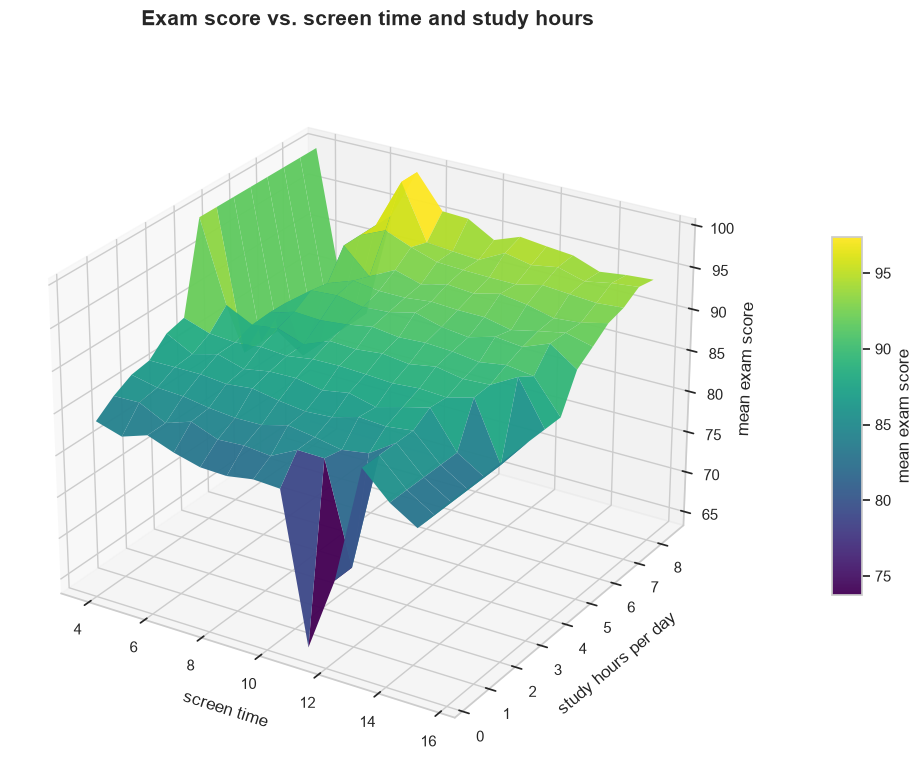

In [16]:
plot_surface("screen_time", "study_hours_per_day",
             "Exam score vs. screen time and study hours", cmap="viridis")

The surface climbs almost entirely along the **study-hours** axis — from ~85 up to ~95+.
Moving along **screen time** alone is nearly flat. The mild positive tilt with screen time is a
*statistical echo*: screen time is largely made up of study, social-media and Netflix hours, so
more screen time often just means more studying. **Hours studied is the real driver; raw screen
time is not.**

### 9.2 The dramatic one: previous GPA × study hours

This pair produces the **steepest surface in the entire dataset** (≈30-point range).

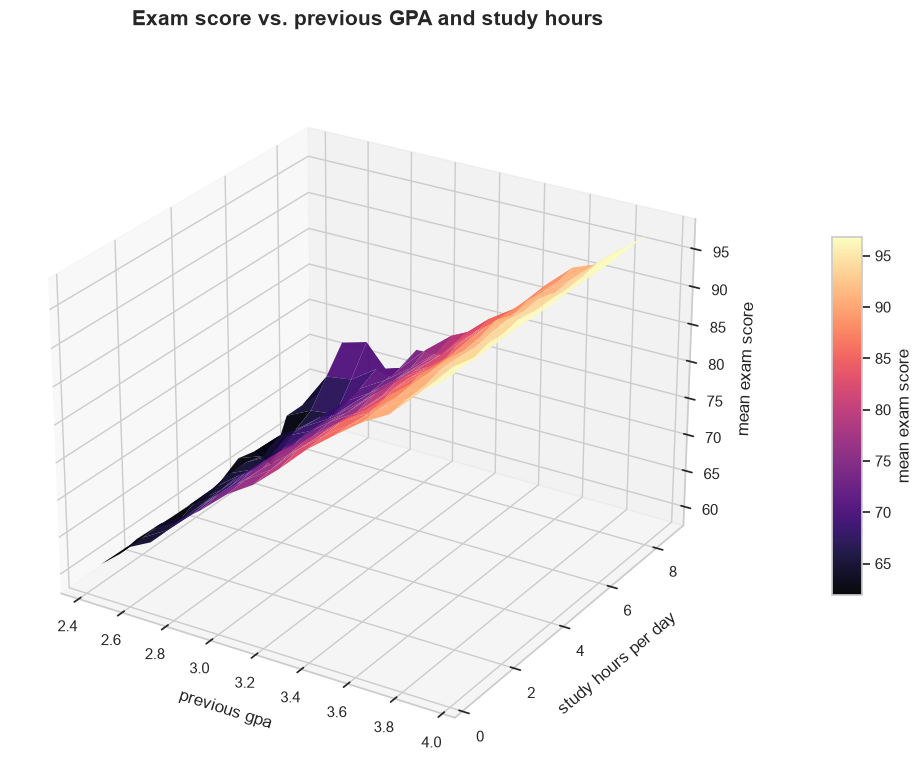

In [17]:
plot_surface("previous_gpa", "study_hours_per_day",
             "Exam score vs. previous GPA and study hours", cmap="magma")

A **cliff**. Almost all the height comes from the **previous-GPA** axis — the surface ramps
from the mid-70s to ~100 as GPA rises. Study hours add only a gentle secondary lift on top.
This is the central finding of the whole notebook, now in 3D: **past performance sets the
plateau; effort nudges you around on it.**

### 9.3 The best *habit × psychology* interaction: study hours × motivation

Once we set previous GPA aside, this is the most structured surface — where **effort meets mindset**.

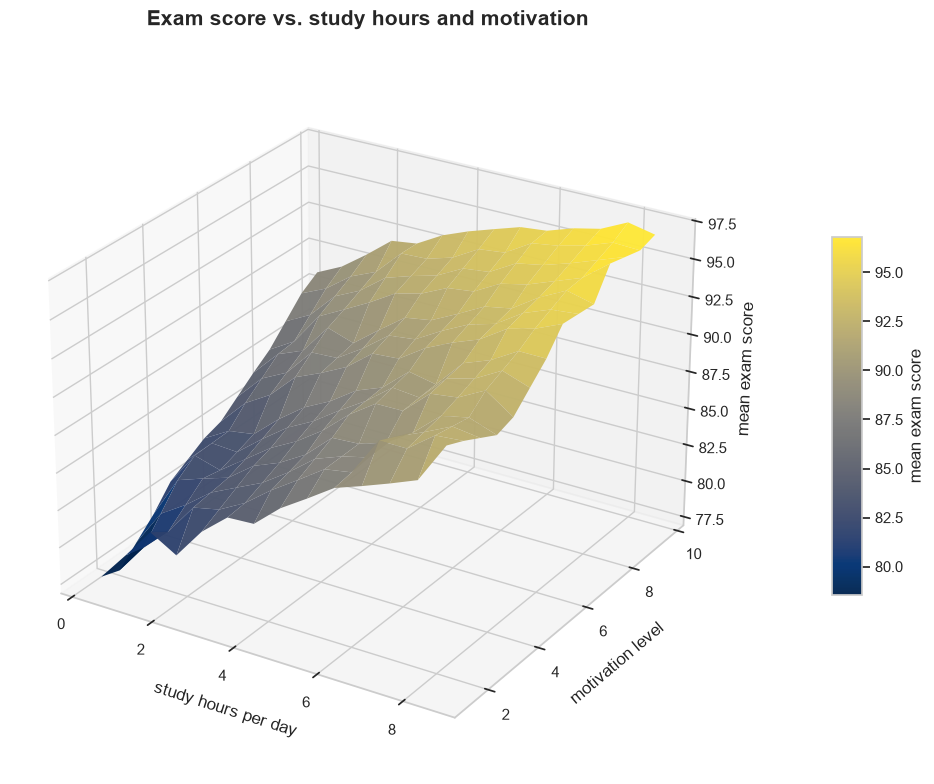

In [18]:
plot_surface("study_hours_per_day", "motivation_level",
             "Exam score vs. study hours and motivation", cmap="cividis")

Here both axes genuinely contribute, and they **compound**: the peak sits in the far corner
where students are *both* highly motivated *and* putting in the hours, while the low corner
(little effort, little motivation) sags noticeably. Neither alone is enough — it's the
**combination** that lifts the score. This is the kind of synergy a 2D chart can't show.

## 10. Myth-busting: predictions the data overturns

Some relationships feel so obvious we'd happily bet on them *before* plotting. Let's write down
those predictions — then let the data answer. Several of our "common sense" guesses turn out to be
flatly wrong.

### 10.1 Three confident predictions — all flat in reality

- **Attendance:** *"Students who attend more classes must score higher."*
- **Time management:** *"Better time-management skills should mean better grades."*
- **Distraction:** *"More time on social media should drag scores down."*

The grey bars are reality; the dashed coral line is what we *expected* to see.

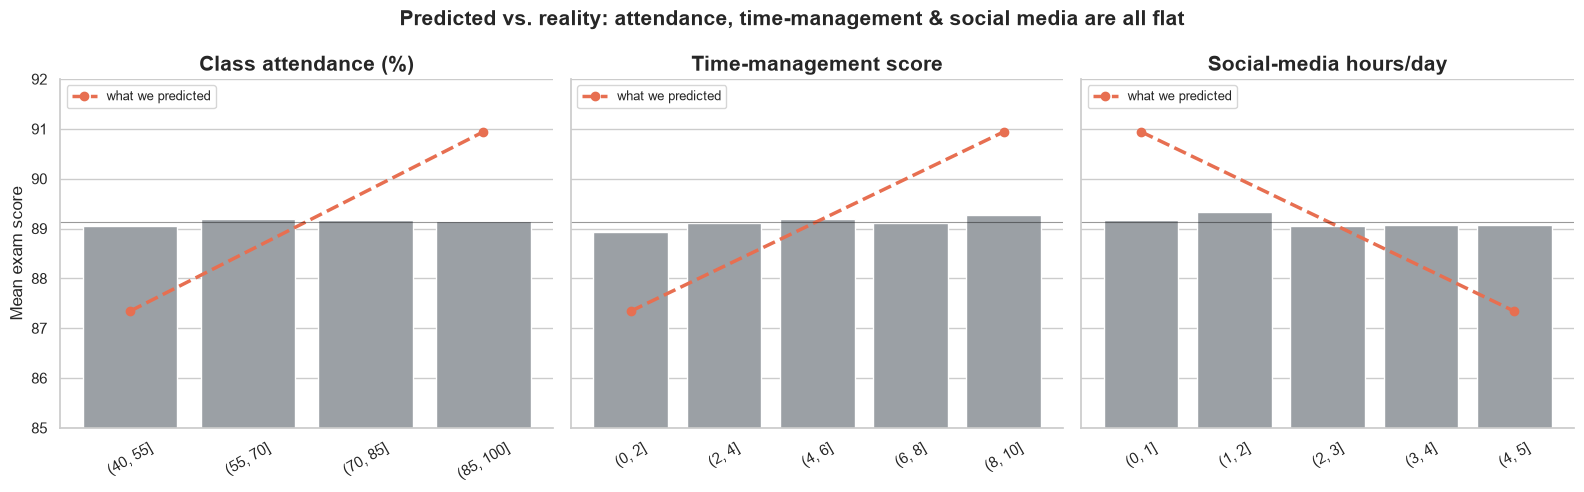

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
specs = [
    ("attendance_percentage", [40, 55, 70, 85, 100], "Class attendance (%)", "up"),
    ("time_management_score",  [0, 2, 4, 6, 8, 10],   "Time-management score", "up"),
    ("social_media_hours",     [0, 1, 2, 3, 4, 5],    "Social-media hours/day", "down"),
]
grand = df["exam_score"].mean()
for ax, (col, bins, xlab, direction) in zip(axes, specs):
    g = df.groupby(pd.cut(df[col], bins), observed=True)["exam_score"].mean()
    labels = [str(i) for i in g.index]
    sns.barplot(x=labels, y=g.values, color=MUTED, ax=ax)
    n = len(g)
    yhi, ylo = grand + 1.8, grand - 1.8
    pred = (ylo, yhi) if direction == "up" else (yhi, ylo)   # naive expected trend
    ax.plot([0, n - 1], pred, ls="--", lw=2.5, color=WARM, marker="o",
            label="what we predicted")
    ax.axhline(grand, color="black", lw=.8, alpha=.4)
    ax.set_title(xlab)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper left", fontsize=9)
axes[0].set_ylabel("Mean exam score")
plt.ylim(85, 92)
fig.suptitle("Predicted vs. reality: attendance, time-management & social media are all flat",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Verdict: contradicted.** All three bars stay pinned within ~1 point of the overall average
(black line), while our predicted trends (coral) go nowhere near them. Whether a student attends
55% or 100% of classes, rates their time-management 2 or 10, or spends 0 or 5 hours a day on social
media, the expected exam score barely budges. These "obvious" levers simply don't pull in this data.

### 10.2 The tutoring twist: right about grades, wrong about dropout

**Prediction:** *"Access to tutoring should both raise exam scores **and** lower dropout risk."*

This one is half-right in a genuinely surprising way.

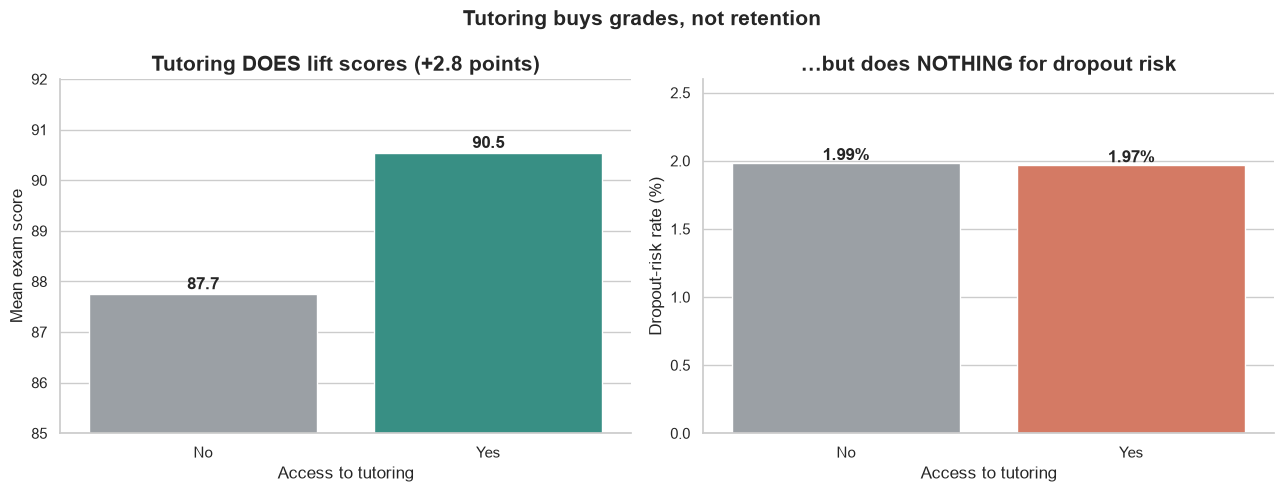

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = df.groupby("access_to_tutoring")["exam_score"].mean().reindex(["No", "Yes"])
sns.barplot(x=sc.index, y=sc.values, hue=sc.index,
            palette={"No": MUTED, "Yes": ACCENT}, legend=False, ax=axes[0])
for i, v in enumerate(sc.values):
    axes[0].text(i, v + 0.1, f"{v:.1f}", ha="center", fontweight="bold")
axes[0].set_ylim(85, 92)
axes[0].set_title(f"Tutoring DOES lift scores (+{sc['Yes'] - sc['No']:.1f} points)")
axes[0].set_xlabel("Access to tutoring")
axes[0].set_ylabel("Mean exam score")

dr = (df.groupby("access_to_tutoring")["dropout_risk"]
        .apply(lambda s: (s == "Yes").mean() * 100).reindex(["No", "Yes"]))
sns.barplot(x=dr.index, y=dr.values, hue=dr.index,
            palette={"No": MUTED, "Yes": WARM}, legend=False, ax=axes[1])
for i, v in enumerate(dr.values):
    axes[1].text(i, v + 0.02, f"{v:.2f}%", ha="center", fontweight="bold")
axes[1].set_ylim(0, 2.6)
axes[1].set_title("…but does NOTHING for dropout risk")
axes[1].set_xlabel("Access to tutoring")
axes[1].set_ylabel("Dropout-risk rate (%)")

fig.suptitle("Tutoring buys grades, not retention", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Verdict: half-confirmed, half-contradicted.** Tutoring is one of the *few* levers that actually
moves the exam score — students with access average **90.5 vs 87.8** (+2.8 points), making it more
effective than diet, income or internet combined. Yet the dropout-risk rate is **identical**
(1.97% vs 1.99%). The students most likely to leave aren't held back by a lack of academic help —
remember from §8 that dropout is an *emotional* signal (stress + collapsed motivation). **Tutoring
fixes the grade problem it's aimed at, but it can't touch the wellbeing problem that drives students out.**

## 11. The story you can tell

Putting the chapters together, here's the narrative this data supports:

> **"Grades have momentum, but people have limits."**

1. **Past performance is destiny.** A student's previous GPA predicts their exam score almost
   perfectly (r ≈ 0.93) — it overwhelms every habit and circumstance we measured.

2. **The advantages we obsess over barely register.** Diet, family income, internet quality,
   sleep, attendance and time-management are all statistically flat against the exam score.
   The "level playing field" is more real here than we'd expect.

3. **The one habit you control that *works* is your environment.** Swapping the dorm for a quiet
   room or library is worth ~6 points — more than diet, income and internet combined.

4. **Motivation and anxiety are mirror images** (r = −0.92). They form the emotional spine of the
   student experience.

5. **Dropout risk is an emotional alarm, not an academic one.** The students most likely to leave
   look academically average — but they are highly stressed and barely motivated. If you want to
   catch them, watch their *wellbeing*, not their grades.

6. **Our intuitions are unreliable here.** Attendance, time-management and social-media use — all
   things we'd confidently bet on — turned out flat. And **tutoring** is a real lever for *grades*
   (+2.8 points) yet does nothing for *dropout risk*: it fixes the academic problem but not the
   human one.

**The takeaway for a school:** exam scores are largely set by prior achievement, so chasing
marginal habit tweaks won't move them much. But **stress and motivation** are where students are
quietly falling through the cracks — and that's where intervention actually matters.